Data loaded successfully!
Dataset Shape: (10000, 14)

--- First 5 Rows ---
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HD

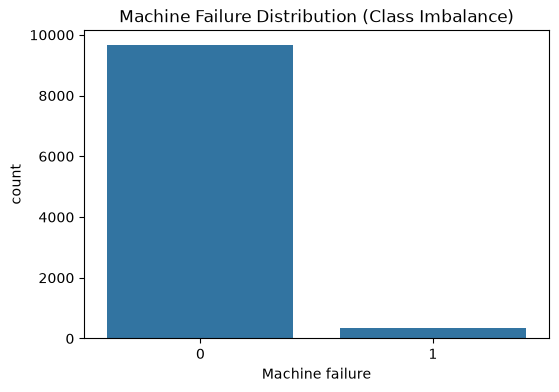

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('ai4i2020.csv')
    print("Data loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")

# first 5 rows
print("\n--- First 5 Rows ---")
print(df.head())

# (Class Imbalance) testing
if 'Machine failure' in df.columns:
    print("\n--- Class Imbalance Check ---")
    print(df['Machine failure'].value_counts(normalize=True) * 100)
    
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Machine failure')
    plt.title("Machine Failure Distribution (Class Imbalance)")
    plt.show()

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.99      0.99      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865

ROC-AUC Score: 0.9996


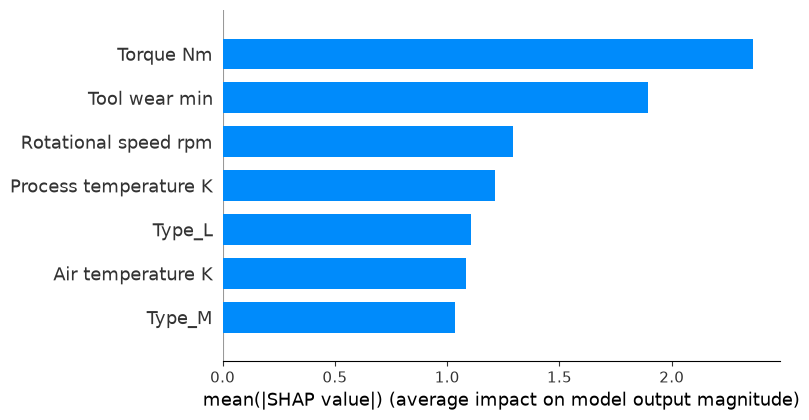

In [ ]:
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Data preprocessing and column cleenup 
df_clean = df.drop(columns=['UDI', 'Product ID'])
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

#  [, ], < etc. remove
df_clean.columns = [re.sub(r'[\[\]<]', '', col) for col in df_clean.columns]

X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']

# 2.  Data balancing with SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Train & Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# 4. XGBoost model training
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# 5. performance check
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("--- Model Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 6. SHAP Explainability (Graph formation)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")